[ 0.01592022  0.14151505  0.28394933  0.44903512  0.52176774  0.63205737
  0.70470029  0.82031846  0.89750356  0.96352025  0.99028237  1.05584589
  1.05070984  1.01788568  1.00802224  1.01933952  0.88954084  0.92068812
  0.7870094   0.73523725  0.55814133  0.52039213  0.3413134   0.28586066
  0.13654533 -0.00536607 -0.13393678 -0.26741291 -0.43138516 -0.47602155
 -0.64410054 -0.6499837  -0.73312484 -0.8579122  -0.8518995  -0.94032655
 -0.98488187 -0.955771   -0.94811188 -0.9233558  -0.83464047 -0.81981475
 -0.78297719 -0.66018408 -0.52175476 -0.43352059 -0.2985494  -0.17050787
 -0.09719512  0.06496001]
[1.05821543e+00 1.14645049e+00 1.34581732e+00 1.41858273e+00
 1.55679876e+00 1.66556550e+00 1.69590900e+00 1.87629057e+00
 1.88397737e+00 1.98241255e+00 2.00801998e+00 2.01725038e+00
 2.05708764e+00 2.08542580e+00 2.04112290e+00 1.98770488e+00
 1.97614737e+00 1.86041176e+00 1.74447908e+00 1.74164175e+00
 1.58515520e+00 1.51573225e+00 1.40112734e+00 1.29072541e+00
 1.13922051e+00 9.668349

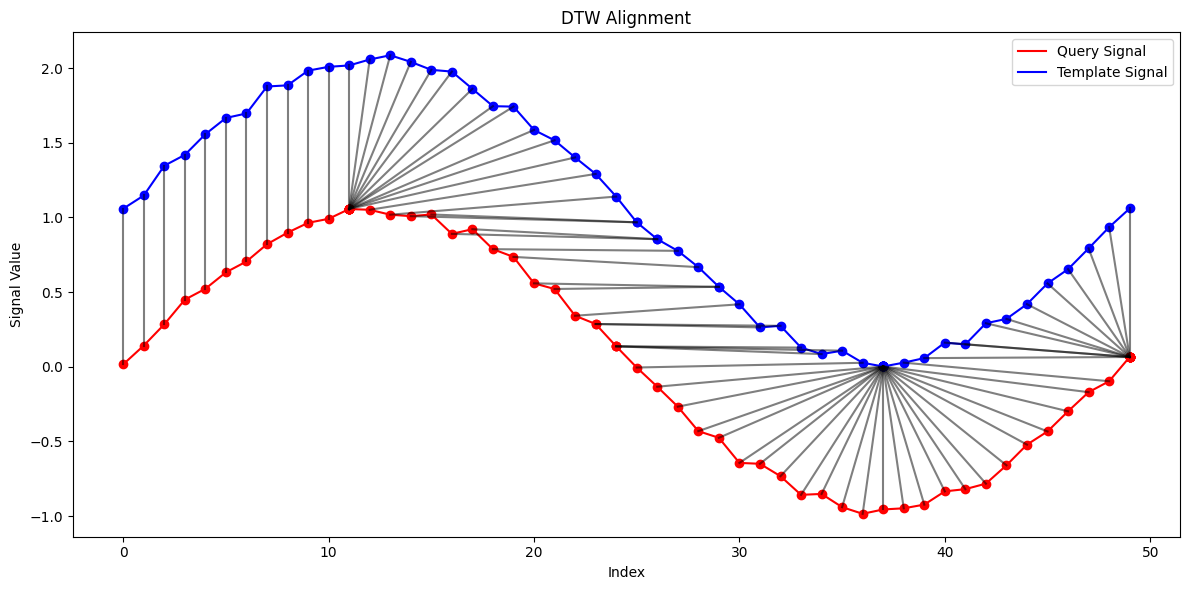

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dtw import *
from copy import deepcopy


def viz(Q, T, ind1, ind2, fname):
    # Convert to numpy arrays for ease of indexing
    Q = np.array(Q)
    T = np.array(T)

    # Plot the query and template signals with alignment lines
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(Q)), Q, 'r-', label='Query Signal')
    plt.plot(range(len(T)), T, 'b-', label='Template Signal')

    # Plot the alignment lines
    for i, j in zip(ind1, ind2):
        plt.plot([i, j], [Q[i], T[j]], 'k-', alpha=0.5)

    plt.scatter(ind1, Q[ind1], color='red')
    plt.scatter(ind2, T[ind2], color='blue')

    # Labeling the plot
    plt.xlabel('Index')
    plt.ylabel('Signal Value')
    plt.legend()
    plt.title('DTW Alignment')

    plt.tight_layout()
    plt.savefig(fname, dpi = 300)
    plt.show()


# List 1
idx1 = np.linspace(0, 6.28, num = 50)
query = np.sin(idx1) + np.random.uniform(size = 50)/10.0
print (query)

# List 2 [USE any one of the options]
# Option 1.
# idx2 = np.linspace(0, 6.28, num = 100)
# template = np.cos(idx2)
# print (template)

# Option 2.
idx2 = np.linspace(0, 6.28, num = 50)
template = np.sin(idx2) + np.random.uniform(size = 50)/10.0 + 1
print (template)

# Define the distance metric (e.g., Euclidean distance)
dist = lambda x, y: np.abs(x - y)

# Find the best match with the canonical recursion formula
alignment = dtw(query, template, dist)
cost, _, _, (ind1, ind2) = deepcopy(alignment)
print (cost)
print (ind1)
print (ind2)

viz(query, template, ind1, ind2, 'DTW_Render.png')

